# Implement folder Planck equation
Find optimal concentration schedule / optimal antigen using analytical formula



In [ ]:
import numpy as np
import torch
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")
import numpy as np

from fokker_planck import run_fp, plot_fp_density_time_dim, LAM, KBT, E_A, N_MAX, D

T=140


0.0858041424906596


In [6]:
import numpy as np
import copy
print(f"\nRunning FP simulation for T={T} seconds")
fp_ctx = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t, v: 170.0,
    T=T,
    verbose=False
)










Running FP simulation for T=140 seconds


### Compute C* with one round of convergence

c*(t) at the FP snapshots:
t= 0.000  c*=57.8451
t= 0.005  c*=57.8588
t= 0.010  c*=57.8724
t= 0.015  c*=57.886
t= 0.020  c*=57.8997


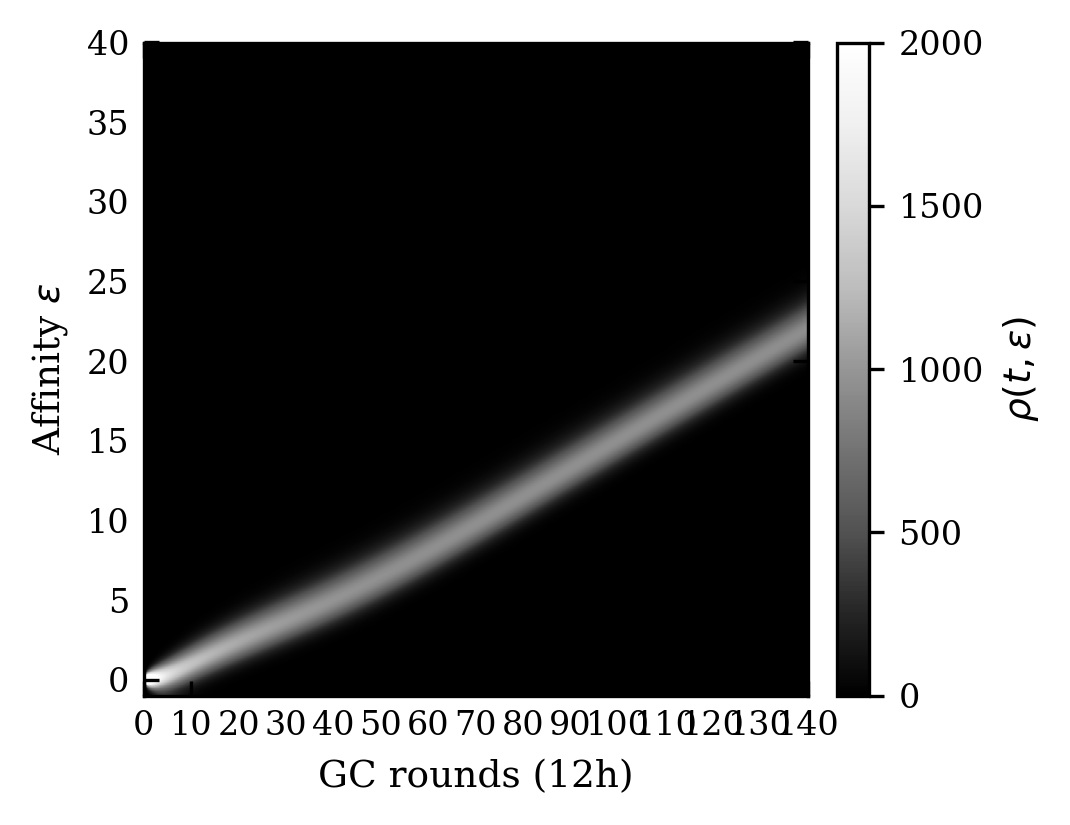

In [7]:
import numpy as np

# ---------- grid measures (time-invariant) ----------
def _grid_measures(fp_ctx):
    axes  = fp_ctx["axes"]
    N_h   = len(axes)
    d_h   = axes[0][1] - axes[0][0]
    dH    = d_h ** N_h
    h_mesh = np.meshgrid(*axes, indexing="ij")  # list length N_h
    return axes, h_mesh, dH

# ---------- E_stack at a given time index k ----------
def _E_stack_at_k(fp_ctx, k, h_mesh):
    """
    Build E_stack_k[v, ...] = E_v(h, t_k) with S(t_k) from get_S.
    """
    times = fp_ctx["times"]
    get_S = fp_ctx["get_S"]                       # callable: t -> S_mat (N_h, n_A)
    S_k   = get_S(float(times[k]))                # (N_h, n_A)
    E_stack_k = np.tensordot(S_k.T, np.stack(h_mesh, axis=0), axes=(1, 0))
    # shape: (n_A, ...grid...)
    return E_stack_k

# ---------- ⟨log P_Ag + log P_T⟩_pop for a scalar C at time index k ----------
def avg_log_terms_given_C(C, k, fp_ctx, *, kBT, E_a):
    """
    Return <log P_Ag + log P_T>_pop and also (P_Ag + P_T)_pop at snapshot k,
    assuming every antigen has concentration C (scalar).
    """
    axes, h_mesh, dH = _grid_measures(fp_ctx)
    rho     = fp_ctx["rho_t"][k]                       # (...grid...)

    # time-dependent energies via get_S(t_k)
    E_stack = _E_stack_at_k(fp_ctx, k, h_mesh)         # (n_A, ...)

    n_A     = E_stack.shape[0]
    C_vec   = np.full(n_A, float(C), dtype=float)
    C_tot   = C_vec.sum()

    # P_Ag
    exp_term  = np.exp((E_stack - E_a) / kBT)                # (n_A, ...)
    numer     = (C_vec.reshape((n_A,) + (1,)*rho.ndim) * exp_term).sum(axis=0)
    P_Ag      = numer / (1.0 + numer)

    # P_T  (depends only on C_tot)
    Phi       = np.exp(E_stack / kBT).sum(axis=0)            # (...)

    # population-weighted averages
    N_pop     = rho.sum() * dH
    w_pop     = rho / N_pop


    # Gates

    # IMPORTANT: recompute Phi_bar for THIS s2
    Phi_bar  = (w_pop * Phi).sum() * dH
    P_T       = Phi / (Phi + Phi_bar / C_tot)

    avg_log   = (w_pop * (np.log(P_Ag) + np.log(P_T))).sum() * dH
    P_sum_pop = (w_pop * (P_Ag + P_T)).sum() * dH
    return avg_log, P_sum_pop

# ---------- solve c*(t_k) for all snapshots ----------
def solve_c_star_over_time(fp_ctx, *, lam=1.0, kBT, E_a,
                           u0=np.log(1.0), newton_maxit=5, newton_tol=1e-10):
    """
    For each k, solve for c* > 0 such that
        <log P_Ag + log P_T>_pop(C=c*) = -lam
    with time-varying S(t_k).
    Newton in u=log C, derivative: d/du <log P_Ag + log P_T> = 2 - (P_Ag+P_T)_pop.
    """
    times  = fp_ctx["times"]
    K      = len(times)
    c_star = np.empty(K, dtype=float)

    for k in range(K):
        u = float(u0)
        for it in range(newton_maxit):
            avg_log, Psum = avg_log_terms_given_C(np.exp(u), k, fp_ctx, kBT=kBT, E_a=E_a)
            g  = avg_log + lam
            if abs(g) < newton_tol:
                break
            dg = 2.0 - Psum
            step = g / (dg if abs(dg) > 1e-8 else np.sign(dg)*1e-8)
            u   -= step
        else:
            # fallback: bracketing + bisection
            def F(u_): return avg_log_terms_given_C(np.exp(u_), k, fp_ctx, kBT=kBT, E_a=E_a)[0] + lam
            u_lo, u_hi = u - 20.0, u + 20.0
            g_lo, g_hi = F(u_lo), F(u_hi)
            tries = 0
            while g_lo * g_hi > 0 and tries < 30:
                u_lo -= 5.0; u_hi += 5.0
                g_lo, g_hi = F(u_lo), F(u_hi); tries += 1
            for _ in range(10):
                u_mid = 0.5*(u_lo+u_hi); g_mid = F(u_mid)
                if g_mid > 0: u_hi = u_mid
                else:         u_lo = u_mid
            u = 0.5*(u_lo+u_hi)

        c_star[k] = np.exp(u)

    return np.array(times), c_star

times, c_star = solve_c_star_over_time(fp_ctx, lam=LAM, kBT=KBT, E_a=E_A)
print("c*(t) at the FP snapshots:")
for t, c in zip(times[:5], c_star[:5]):
    print(f"t={t:6.3f}  c*={c:.6g}")

def make_get_C_from_cstar(times, c_star):
    times = np.asarray(times, dtype=float)
    c_star = np.asarray(c_star, dtype=float)
    t0, tf = float(times[0]), float(times[-1])

    def get_C_star(t, v):
        # same concentration for all antigens v
        t = float(t)
        if t <= t0:
            return float(c_star[0])
        if t >= tf:
            return float(c_star[-1])
        return float(np.interp(t, times, c_star))
    return get_C_star

get_C_star = make_get_C_from_cstar(times, c_star)

fp_ctx = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star,
    T=T,
    verbose=False
)


plot_fp_density_time_dim(fp_ctx, sol=None, disp_step=10, cmap="Greys_r")






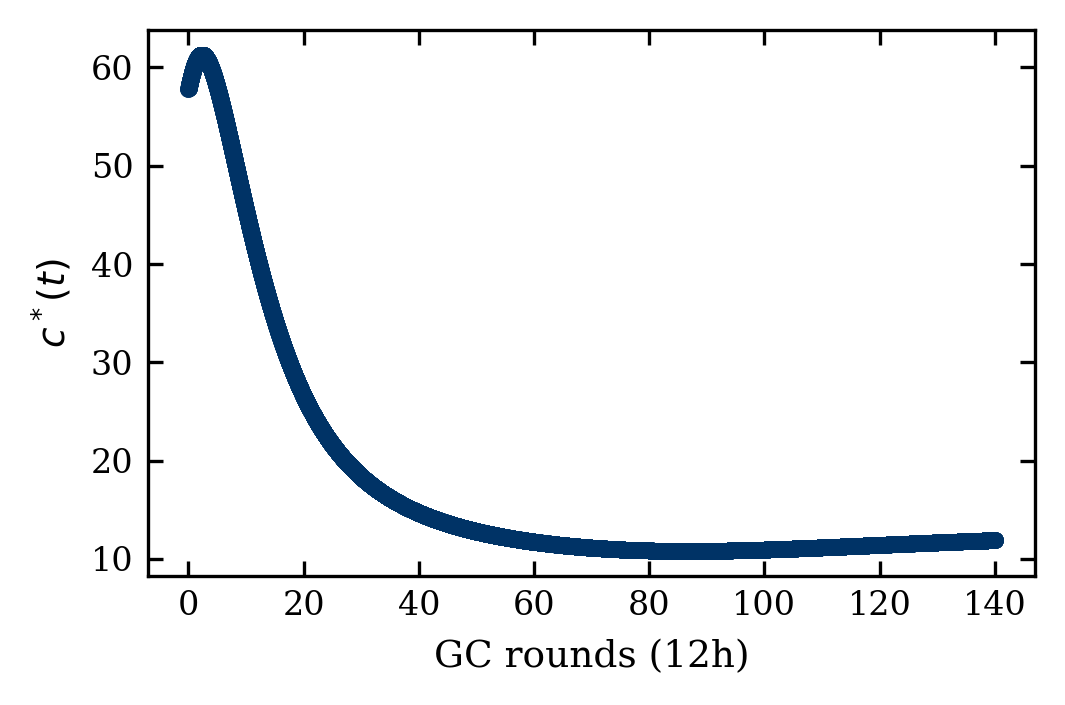

In [8]:
import matplotlib.pyplot as plt

# 1. Apply the publication-ready formatting style
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 3,
    "figure.figsize": (3.4, 2.2),  # Keeping your requested aspect ratio
    "figure.dpi": 300,
    "font.family": "serif",
})

# 2. Create Figure and Axes
fig, ax = plt.subplots()

# 3. Plot the data
# Using the "Navy Blue" from the previous palette for consistency
ax.plot(times, c_star, 
        marker='o', 
        markersize=3, 
        linewidth=1.0, 
        color='#003366',  # Professional dark blue
        label=r"$c^*(t)$")

# 4. Set Labels
ax.set_xlabel(r"GC rounds (12h)")
ax.set_ylabel(r"$c^*(t)$")

# 5. Apply aesthetic preferences (ticks in, no grid)
ax.tick_params(direction="in", top=True, right=True)
ax.grid(False)

# 6. Layout and Save
plt.tight_layout(pad=0.2)
# plt.savefig("c_star_vs_time.pdf")  # Uncomment to save
plt.show()


### Compute C* with multiple rounds of convergence

In [ ]:
import numpy as np



def iterate_fp_and_cstar(initial_fp_ctx, num_iterations, T, lam, kBT, E_a):
    """
    Alternates between solving for the optimal concentration C*(t) and 
    running the Fokker-Planck solver to find the new trajectory/distribution.
    """
    c_star_history = []
    fp_ctx = initial_fp_ctx
    
    for i in range(num_iterations):
        # 1. Obtain optimal concentration from the current FP context
        times, c_star = solve_c_star_over_time(fp_ctx, lam=lam, kBT=kBT, E_a=E_a)
        
        # Save the result for plotting convergence later
        c_star_history.append((times.copy(), c_star.copy()))
        
        print(f"Iteration {i+1}/{num_iterations} complete.")
        
        # 2. Create the interpolation function for the next FP run
        get_C_star = make_get_C_from_cstar(times, c_star)
        
        # 3. Run the Fokker-Planck solver with the updated concentration profile
        fp_ctx = run_fp(
            get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h1 and h2
            get_C=get_C_star,
            T=T,
            verbose=False
        )
        
    return c_star_history, fp_ctx

# TODO
num_iterations = 10
fp_ctx_init = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t, v: 170.0,
    T=T,
    verbose=False
)
c_star_history, fp_ctx_star = iterate_fp_and_cstar(fp_ctx_init, num_iterations, T=T, lam=LAM, kBT=KBT, E_a=E_A)




Iteration 1/10 complete.


KeyboardInterrupt: 

: 

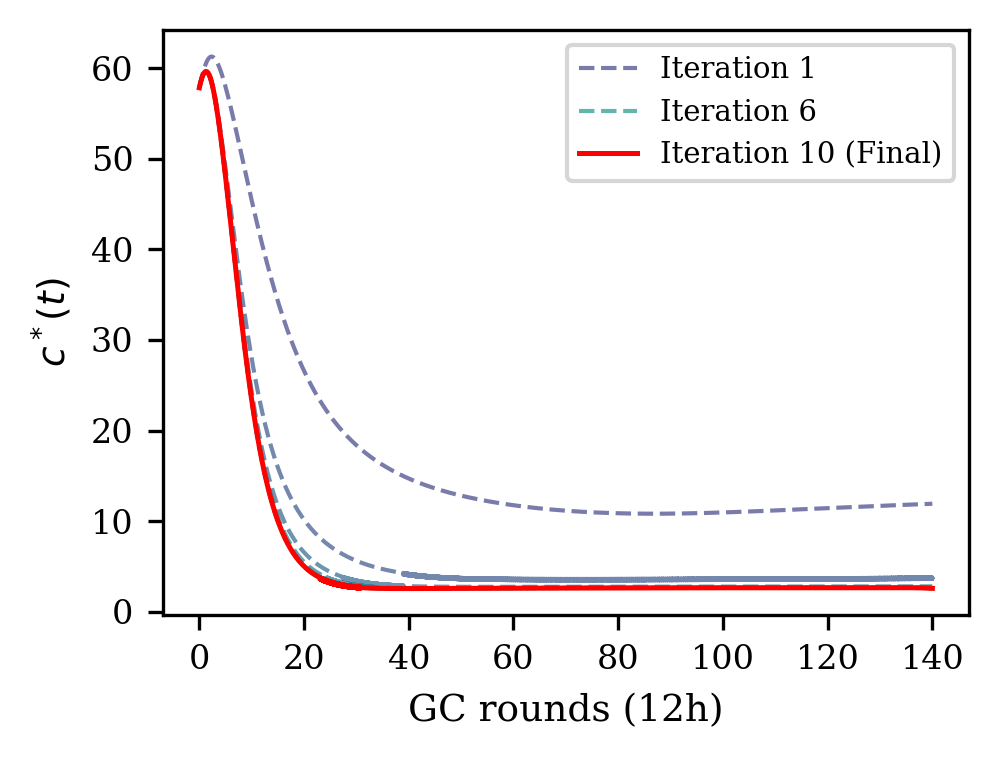

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_c_star_convergence(c_star_history):
    """Generates a plot showing the convergence of optimal concentration c*(t)."""
    
    # Global Style Settings
    plt.rcParams.update({
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "lines.markersize": 3,
        "figure.figsize": (3.4, 2.6), # Standard column width
        "figure.dpi": 300,
        "font.family": "serif",
    })

    fig, ax = plt.subplots()
    
    num_iters = len(c_star_history)
    # Generate a sequence of colors to visualize progression
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, num_iters))
    
    for i, (times, c_star) in enumerate(c_star_history):
        # Visually distinct styling for the final convergence iteration
        if i == num_iters - 1:
            ax.plot(times, c_star, color='red', marker='', linestyle='-', 
                    linewidth=1.2, label=f"Iteration {i+1} (Final)", zorder=3)
        else:
            # Intermediate iterations fade from dark to light
            ax.plot(times, c_star, color=colors[i], marker='', linestyle='--', 
                    linewidth=1.0, alpha=0.7, label=f"Iteration {i+1}", zorder=2)

    ax.set_xlabel(r"GC rounds (12h)")
    ax.set_ylabel(r"$c^*(t)$")
    
    # Optional styling adjustments based on your reference
    # ax.tick_params(direction="in", top=True, right=True)
    ax.grid(False)
    
    # Prevent legend clutter if there are many iterations
    if num_iters <= 5:
        ax.legend(frameon=True, loc='best', fontsize=7)
    else:
        # Show first, middle, and last iteration in legend
        handles, labels = ax.get_legend_handles_labels()
        display_indices = [0, num_iters // 2, -1]
        ax.legend([handles[j] for j in display_indices], 
                  [labels[j] for j in display_indices], 
                  frameon=True, loc='best', fontsize=7)

    plt.tight_layout()
    plt.show()

# Example usage:
plot_c_star_convergence(c_star_history)
c_star=c_star_history[-1][1]


### Study the effect of c on the optimal schedule and optimal antigen

In [13]:
fp_ctx_star= run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t, v: 170,
    T=T,
    verbose=False
)

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- Helper Functions ---
def safe_log(x, eps=1e-12):
    return np.log(np.maximum(x, eps))

def _grid_measures(fp_ctx):
    axes  = fp_ctx["axes"]
    N_h   = len(axes)
    d_h   = axes[0][1] - axes[0][0]
    dH    = d_h ** N_h
    h_mesh = np.meshgrid(*axes, indexing="ij")
    return axes, h_mesh, dH

def _E_stack_at_k(fp_ctx, k, h_mesh):
    times = fp_ctx["times"]
    if "get_S" in fp_ctx:
        S_k = fp_ctx["get_S"](float(times[k]))
    else:
        S_k = fp_ctx["S_mat"]
    return np.tensordot(S_k.T, np.stack(h_mesh, axis=0), axes=(1, 0)), S_k

def _coerce_h_vec(h, N_h):
    if np.isscalar(h):
        vec = np.zeros(N_h, dtype=float); vec[0] = float(h); return vec
    h_arr = np.asarray(h, dtype=float).ravel()
    if h_arr.size == N_h:
        return h_arr
    if h_arr.size < N_h:
        vec = np.zeros(N_h, dtype=float); vec[:h_arr.size] = h_arr; return vec
    return h_arr[:N_h]

# --- 1. Calculation Function ---
def calculate_gamma_omega(fp_ctx_final, h_vals, C_values, *,
                          kBT, E_a, lam, N_max,
                          t_index=None, t_time=70):
    """
    Computes Gamma and Omega curves. 
    Returns a dictionary containing all computed arrays and key scalar values.
    """
    # Grid and Time Setup
    axes, h_mesh, dH = _grid_measures(fp_ctx_final)
    times = np.asarray(fp_ctx_final["times"], dtype=float)

    if t_index is not None:
        k = int(t_index)
    elif t_time is not None:
        k = int(np.argmin(np.abs(times - float(t_time)))) 
    else:
        k = len(times) - 1

    rho_f = fp_ctx_final["rho_t"][k]
    E_stack, S_final = _E_stack_at_k(fp_ctx_final, k, h_mesh)
    N_h, n_A = S_final.shape

    # Precompute population integrals
    Phi_grid = np.exp(E_stack / kBT).sum(axis=0)
    N_pop   = rho_f.sum() * dH
    w_pop   = rho_f / N_pop
    Phi_bar = (w_pop * Phi_grid).sum() * dH

    # Storage for results
    results = {
        "C": C_values,
        "gamma": {},  # Will store gamma array for each h
        "omega": None,
        "C0": None,   # First C where Omega > 0
        "lambda": lam,
        "max_gamma_locs": {} # Store max (C, Gamma) for each h
    }

    # Calculate Omega (Global) and Gamma (per h)
    # Note: Omega is independent of the specific h we probe, 
    # but we need to loop C to calculate it.
    
    omega_vals = []
    
    # We loop C once to compute Omega and store intermediate grids if needed,
    # or just compute Omega "on the fly" inside the h loop? 
    # Better to compute Omega once since it depends on the population distribution (w_pop).
    
    for C in C_values:
        C = float(C)
        C_tot = C * n_A
        
        # Omega Calculation
        exp_term_grid = np.exp((E_stack - E_a) / kBT)
        numer_grid    = (C * exp_term_grid).sum(axis=0)
        PAg_grid      = numer_grid / (1.0 + numer_grid)
        PT_grid       = Phi_grid / (Phi_grid + Phi_bar / C_tot)

        avg_log = (w_pop * (safe_log(PAg_grid) + safe_log(PT_grid))).sum() * dH
        Omega   = 0.0 if N_pop < N_max else max(0.0, lam + avg_log)
        omega_vals.append(Omega)

    omega_vals = np.array(omega_vals)
    results["omega"] = omega_vals

    # Find C0 (First C where Omega > 0)
    idx_positive = np.where(omega_vals > 0)[0]
    if len(idx_positive) > 0:
        results["C0"] = C_values[idx_positive[0]]

    # Compute Gamma for each requested h
    for h in h_vals:
        h_vec = _coerce_h_vec(h, N_h)
        E_pt  = (S_final.T @ h_vec).ravel()
        Phi_pt = np.exp(E_pt / kBT).sum()
        exp_Es_pt = np.exp((E_pt - E_a) / kBT)

        g_vals = []
        for i, C in enumerate(C_values):
            C = float(C)
            C_tot = C * n_A
            Omega = omega_vals[i] # Reuse precalculated Omega

            numer_pt = (C * exp_Es_pt).sum()
            PAg_pt   = numer_pt / (1.0 + numer_pt)
            PT_pt    = Phi_pt / (Phi_pt + Phi_bar / C_tot)

            gamma_pt = lam + safe_log(PAg_pt) + safe_log(PT_pt) - Omega
            g_vals.append(gamma_pt)
        
        g_vals = np.array(g_vals)
        results["gamma"][h] = g_vals
        
        # Find Max Gamma location
        max_idx = np.argmax(g_vals)
        results["max_gamma_locs"][h] = (C_values[max_idx], g_vals[max_idx])

    return results


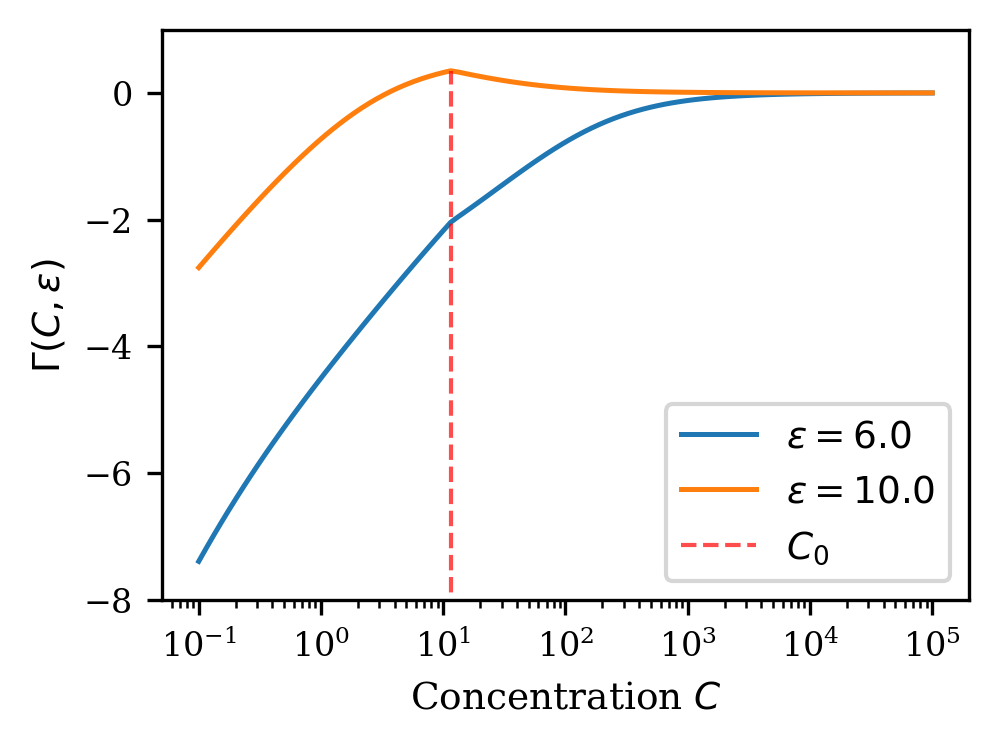

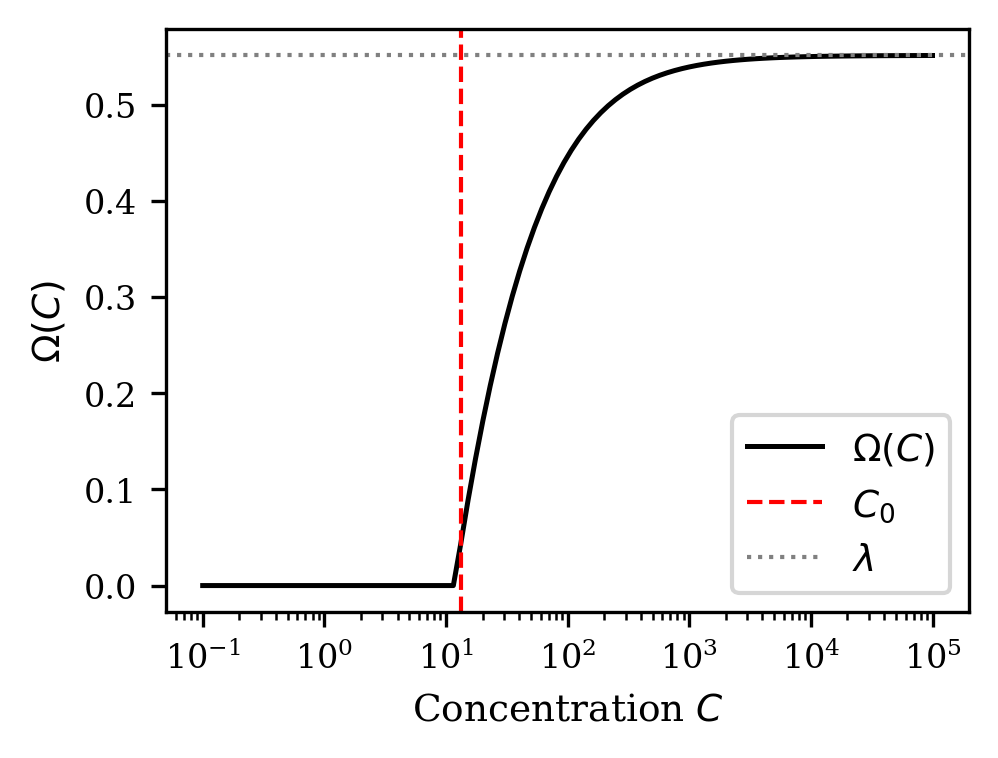

In [21]:

# =========================================================
# 2. Execution & Plotting Phase
# =========================================================

# --- A. Run Calculation ---
# Assuming 'fp_ctx_opt' or similar is your final context variable
# and parameters are defined in your environment.

# Example placeholder call (Uncomment/Modify with your actual variables)
data = calculate_gamma_omega(fp_ctx_star, 
                             h_vals=[6.0, 10.0], 
                             C_values=np.logspace(-1, 5, 100),
                             kBT=KBT, E_a=E_A, lam=LAM, N_max=N_MAX, t_time=140)

# --- B. Plotting Script ---

def plot_gamma_omega(data):
    """Generates two separate plots from the calculated data."""
    
    # Global Style Settings
    plt.rcParams.update({
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "lines.markersize": 4,
        "figure.figsize": (3.4, 2.6), # Standard column width
        "figure.dpi": 300,
        "font.family": "serif",
    })

    # ---------------- FIGURE 1: Gamma vs C ----------------
    fig1, ax1 = plt.subplots()
    
    for h, g_vals in data["gamma"].items():
        # Plot curve
        line, = ax1.plot(data["C"], g_vals, label=rf"$\epsilon={h}$", linewidth=1.2)
        
        # Add vertical drop line for max
        max_C, max_val = data["max_gamma_locs"][h]
    if max_C<1000:

        ax1.vlines(x=max_C, ymin=-15, ymax=max_val, 
                colors='red', linestyles='--', linewidth=1.0, alpha=0.7, label=r"$C_0$")

    ax1.set_xscale("log")
    ax1.set_xlabel(r"Concentration $C$")
    ax1.set_ylabel(r"$\Gamma(C,\epsilon)$")
    ax1.set_ylim(-8, 1) # Adjust as needed
    
    # ax1.tick_params(direction="in", top=True, right=True)
    ax1.grid(False)
    ax1.legend(frameon=True, loc='best')
    
    plt.tight_layout()
    plt.show() # Or fig1.savefig("gamma_plot.pdf")

    # ---------------- FIGURE 2: Omega vs C ----------------
    fig2, ax2 = plt.subplots()
    
    # 1. Plot Omega Curve
    ax2.plot(data["C"], data["omega"], color='black', linestyle='-', linewidth=1.2, label=r"$\Omega(C)$")
    
    # 2. Plot C0 (Vertical Line)
    if data["C0"] is not None:
        ax2.axvline(x=data["C0"], color='red', linestyle='--', linewidth=1.0, 
                    label=r"$C_0$")
        
    # 3. Plot Lambda (Horizontal Asymptote)
    lam_val = data["lambda"]
    ax2.axhline(y=lam_val, color='gray', linestyle=':', linewidth=1.0, 
                label=r"$\lambda$")

    ax2.set_xscale("log")
    ax2.set_xlabel(r"Concentration $C$")
    ax2.set_ylabel(r"$\Omega(C)$")
    # ax2.set_ylim(bottom=-0.1) # Optional: constrain y-view
    
    # ax2.tick_params(direction="in", top=True, right=True)
    ax2.grid(False)
    ax2.legend(frameon=True, loc='best')
    
    plt.tight_layout()
    plt.show() # Or fig2.savefig("omega_plot.pdf")

# Example usage:
plot_gamma_omega(data)